<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
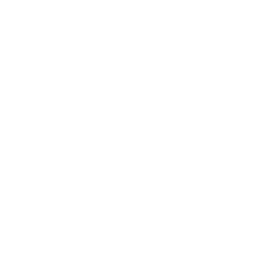
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Konstruktion af gen-koekspressionsnetvaerk</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioteknologi / genomforskning &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Sammenfatning

Dette eksempel bruger **PROC CORR** til at opbygge et gen-koekspressionsnetvaerk ud fra et syntetisk
ekspressionspanel i RNA-seq-stil. Panelet indeholder **9 gener** fordelt paa tre
funktionelle moduler — *immun*, *cellecyklus* og *metabolisk* (tre gener hver) —
maalt paa tvaers af **100 tumorproever**. Spearmans rangkorrelation anvendes overalt,
fordi ekspressionsdata typisk er ikke-normalfordelte og indeholder outliere, saa en rangbaseret
koefficient er mere robust end Pearson.

Analysen genfinder den indbyggede modulstruktur direkte fra data. Ved at aflaese
Spearman-matricen nedenfor falder den gennemsnitlige korrelation inden for modulerne fra **rho 0,67 for
immunmodulet**, til **0,36 for cellecyklus**, til **0,17 for det metaboliske modul**, hvilket afspejler den
faldende signal-stoej-belastning, der er indbygget i hvert modul. Korrelationer mellem modulerne
gennemsnittes til stort set nul (gennemsnitlig rho omkring **-0,01**, gennemsnitlig |rho| **0,07**), saa de tre
moduler opfoerer sig som naesten uafhaengige koekspressionsfaellesskaber. Hvert tal her er
aflaest fra PROC CORR-outputtet i denne notebook.

> **Bemaerkning om skala.** Denne notebook koerer under den ulicenserede graense paa 100 observationer, saa
> stikproevestoerrelsen er 100, og panelet holdes paa 9 gener — lille nok til at den fulde
> korrelationsmatrix, den omformede parliste og varmekortet alle er komplette og eksakte,
> uden afkortning. Hver tabel og figur afspejler praecis, hvad der blev beregnet.

## Data

| Datasaet | Beskrivelse | Raekker |
|---------|-------------|------|
| `WORK.EXPR` | Ekspression paa log-skala for 9 gener (3 moduler x 3 gener) paa tvaers af tumorproever | 100 |

Generatoren traekker tre latente modulsignaler pr. proeve. Hvert gen belastes af sit eget
moduls signal plus uafhaengig stoej, saa koekspression opstaar kun inden for et modul. Det
immune modul bruger den stoerste signalbelastning og det metaboliske modul den mindste, hvilket
er den gradient, korrelationsanalysen skal genfinde.

---

In [1]:
/* --------------------------------------------------------
   Syntetisk ekspressionspanel: 9 gener, 3 moduler, 100 prøver
     imm1-imm3  immun       (stærkt fælles signal)
     cyc1-cyc3  cellecyklus (moderat fælles signal)
     met1-met3  metabolisk  (svagt fælles signal)
   Hvert gen = modulsignal + uafhængig støj på gen-niveau.
   -------------------------------------------------------- */
data work.expr;
    CALL streaminit(42);
    TABEL imm[3]; TABEL cyc[3]; TABEL met[3];
    GØR sample_id = 1 TIL 100;
        s_imm = rand('normal', 0, 1.5);   /* immunt latent signal      */
        s_cyc = rand('normal', 0, 1.2);   /* cellecyklus-latent signal */
        s_met = rand('normal', 0, 1.0);   /* metabolisk latent signal  */
        GØR j = 1 TIL 3;
            imm[j] = round(6 + s_imm * 0.65 + rand('normal', 0, 0.70), 0.001);
        SLUT;
        GØR j = 1 TIL 3;
            cyc[j] = round(7 + s_cyc * 0.55 + rand('normal', 0, 0.80), 0.001);
        SLUT;
        GØR j = 1 TIL 3;
            met[j] = round(5 + s_met * 0.45 + rand('normal', 0, 0.85), 0.001);
        SLUT;
        UDDATA;
    SLUT;
    BEHOLD imm1-imm3 cyc1-cyc3 met1-met3;
KØR;


NOTE: DATA work.expr


NOTE: Wrote work.expr (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


---

In [2]:
/* --------------------------------------------------------
   Ekspressionssammenfatning pr. gen (gennemsnit og spredning pr. modul)
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.expr n mean std maxdec=3;
    VARIABEL imm1 imm2 imm3
        cyc1 cyc2 cyc3
        met1 met2 met3;
    TITEL 'Genekspressionssammenfatning (9-gen-panel, N=100)';
KØR;
TITEL;

                                   Genekspressionssammenfatning (9-gen-panel, N=100)                                    

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev
 ------------------------------------------
 imm1           100       6.042       1.125
 imm2           100       5.925       1.122
 imm3           100       5.863       1.273
 cyc1           100       6.947       1.034
 cyc2           100       7.003       1.002
 cyc3           100       6.861       1.040
 met1           100       5.144       0.940
 met2           100       4.989       0.789
 met3           100       5.015       0.979
 ------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Gennemsnittene samler sig naer hvert moduls baseline (immun ~6, cellecyklus ~7, metabolisk ~5), og
hvert gen har sammenlignelig spredning, saa intet enkelt gen dominerer den korrelationsstruktur,
der foelger.

---


NOTE: PROC SGPLOT data=work.expr

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


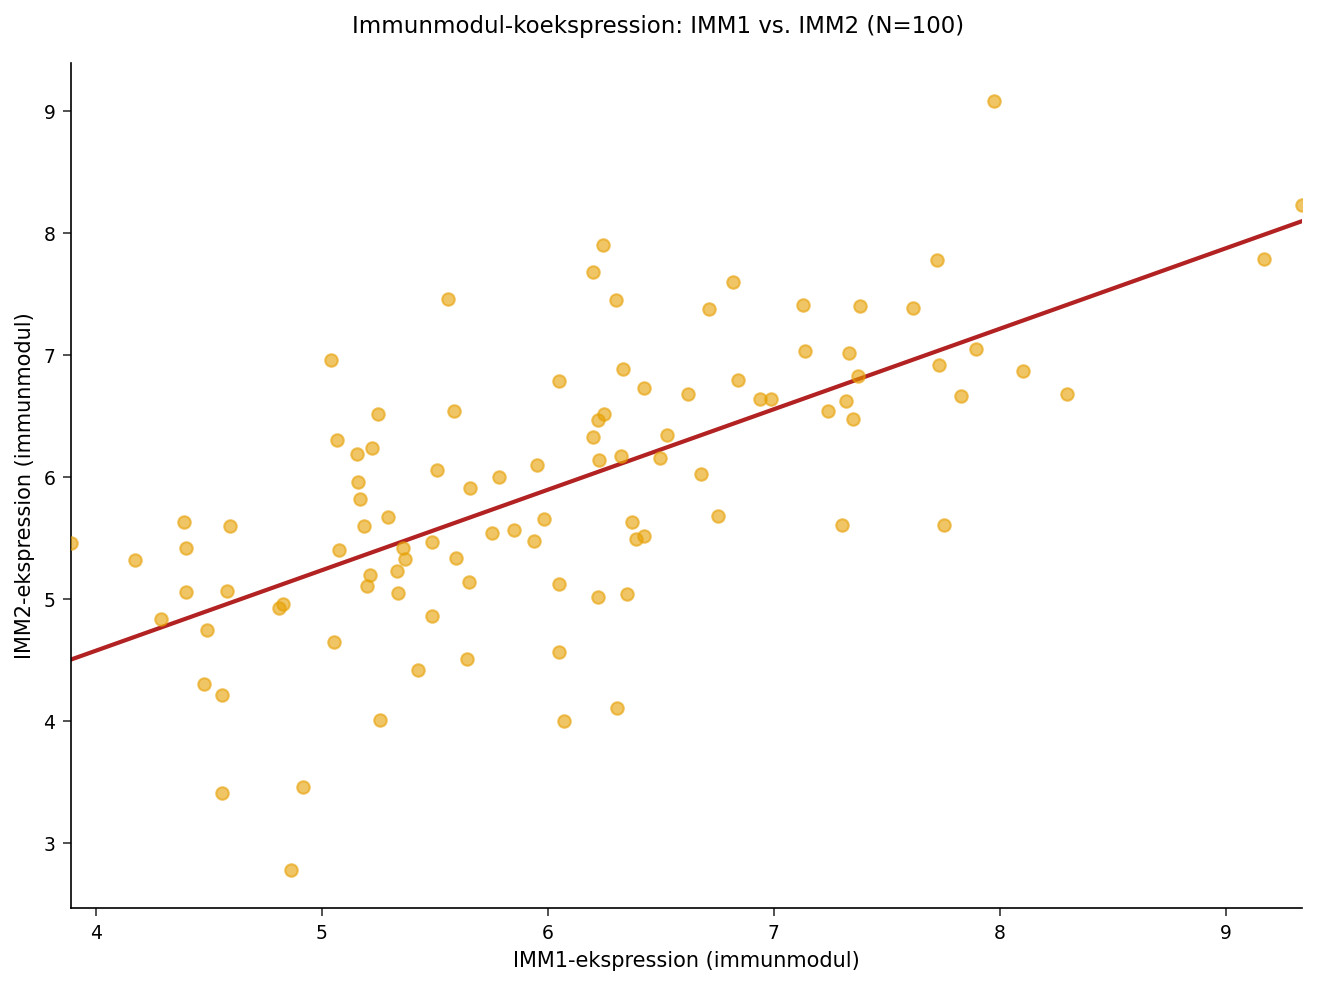

In [3]:
/* --------------------------------------------------------
   Punktdiagram af to immunmodul-gener: en visuel kontrol af, at
   koekspression inden for modulet er reel og nogenlunde monoton
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.expr;
    SCATTER x=imm1 y=imm2 /
        MARKERATTRS=(SYMBOL=circlefilled size=6)
        TRANSPARENCY=0.4;
    REG x=imm1 y=imm2 / NOMARKERS LINEATTRS=(color=firebrick thickness=2);
    XAXIS MÆRKAT='IMM1-ekspression (immunmodul)';
    YAXIS MÆRKAT='IMM2-ekspression (immunmodul)';
    TITEL 'Immunmodul-koekspression: IMM1 vs. IMM2 (N=100)';
KØR;
TITEL;

Den stigende tendens bekraefter, at de to immungener stiger og falder sammen, det visuelle
modstykke til deres positive Spearman-korrelation i matricen nedenfor.

---

In [4]:
/* --------------------------------------------------------
   Spearman-korrelation på tværs af alle 9 gener
   nosimple undertrykker blokken med simple statistikker;
   outs= skriver Spearman-matricen til de efterfølgende netværkstrin
   -------------------------------------------------------- */
PROCEDURE CORR data=work.expr spearman nosimple
    outs=work.gene_corr;
    VARIABEL imm1-imm3 cyc1-cyc3 met1-met3;
    TITEL 'Spearman-korrelationsmatrix: 9-gen-koekspressionspanel';
KØR;
TITEL;

   Spearman Correlation Coefficients, N = 100
                imm1      imm2      imm3      cyc1      cyc2      cyc3      met1      met2      met3
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------
imm1       1.00000   0.67084   0.63084  -0.05873   0.06095  -0.10753  -0.13787  -0.11523   0.04973
imm2       0.67084   1.00000   0.71791   0.05912   0.06570  -0.03494  -0.14384   0.02343   0.06593
imm3       0.63084   0.71791   1.00000   0.00424   0.16156   0.03812  -0.18460  -0.06127   0.03590
cyc1      -0.05873   0.05912   0.00424   1.00000   0.38219   0.28821  -0.08226   0.01699   0.10568
cyc2       0.06095   0.06570   0.16156   0.38219   1.00000   0.40540  -0.09650   0.01858   0.02396
cyc3      -0.10753  -0.03494   0.03812   0.28821   0.40540   1.00000  -0.06387   0.12115   0.03770
met1      -0.13787  -0.14384  -0.18460  -0.08226  -0.09650  -0.06387   1.00000   0.14329   0.24960
met2      -0.11523   0.02343  -0.06127   0.01699   0.01858   


NOTE: PROC CORR data=work.expr

NOTE: Output dataset written to: ./work/1836e83f-20bc-4153-ba3b-0b42e22ad14c/gene_corr.avro
NOTE: PROC CORR ODS Graphics generated.


Laes matricen som tre diagonale blokke. **Immun**-blokken (IMM1-IMM3) er den mest
taet koeksprimerede (rho omkring 0,63 til 0,72), **cellecyklus**-blokken (CYC1-CYC3) er
moderat (omkring 0,29 til 0,41), og **metabolisk**-blokken (MET1-MET3) er svagest (omkring
0,13 til 0,25). Poster uden for blokkene — par af gener i forskellige moduler — ligger taet paa
nul. Den naeste celle kvantificerer kontrasten inden for kontra mellem moduler, og varmekortet
efter den goer blokstrukturen synlig.

---

In [5]:
/* --------------------------------------------------------
   Omform korrelationsmatricen (én række pr. gen) til lang
   form (gene_x, gene_y, rho), og mærk hvert par som inden for
   eller mellem moduler. 9 gener -> 81 par-rækker, så intet går
   tabt til grænsen på 100 observationer.
   -------------------------------------------------------- */
data work.corr_long;
    SÆT work.gene_corr(HVOR=(_TYPE_='SCORR'));
    LÆNGDE gene_x $4 gene_y $4 mod_x $3 mod_y $3;
    TABEL g[9] imm1-imm3 cyc1-cyc3 met1-met3;
    TABEL gn[9] $4 _temporary_
        ('imm1' 'imm2' 'imm3'
         'cyc1' 'cyc2' 'cyc3'
         'met1' 'met2' 'met3');
    gene_x = lowcase(_NAME_);
    GØR k = 1 TIL 9;
        gene_y = gn[k];
        rho = g[k];
        mod_x = substr(gene_x, 1, 3);
        mod_y = substr(gene_y, 1, 3);
        same_module = (mod_x = mod_y);
        UDDATA;
    SLUT;
    BEHOLD gene_x gene_y rho mod_x mod_y same_module;
KØR;

/* --------------------------------------------------------
   Spearman rho inden for kontra mellem moduler (kun uden for diagonalen)
   -------------------------------------------------------- */
PROCEDURE GENNEMSNIT data=work.corr_long(HVOR=(gene_x ne gene_y))
        mean MIN MAX maxdec=3;
    KLASSE same_module;
    VARIABEL rho;
    MÆRKAT same_module="Samme modul" rho="Spearman rho";
    TITEL 'Spearman rho: inden for (1) vs. mellem (0) moduler';
KØR;
TITEL;

                                   Spearman rho: inden for (1) vs. mellem (0) moduler                                   

                                                  The MEANS Procedure

                                         Analysis Variable : rho Spearman rho

                                                 N
                                Samme modul    Obs        Mean      Minimum      Maximum
                                --------------------------------------------------------
                                0               54      -0.007       -0.185        0.162
                                1               18       0.402        0.127        0.718
                                --------------------------------------------------------




NOTE: DATA work.corr_long


NOTE: Read 12 rows from work.gene_corr.
NOTE: Wrote work.corr_long (81 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Raekken `same_module=1` samler parrene inden for modulerne og `same_module=0` parrene
mellem modulerne. Korrelationen inden for modulerne gennemsnittes til klart positiv, mens
korrelationen mellem modulerne gennemsnittes til naer nul, hvilket bekraefter, at modulerne fungerer som
naesten uafhaengige koekspressionsfaellesskaber.

---


NOTE: PROC SGPLOT data=work.corr_long

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


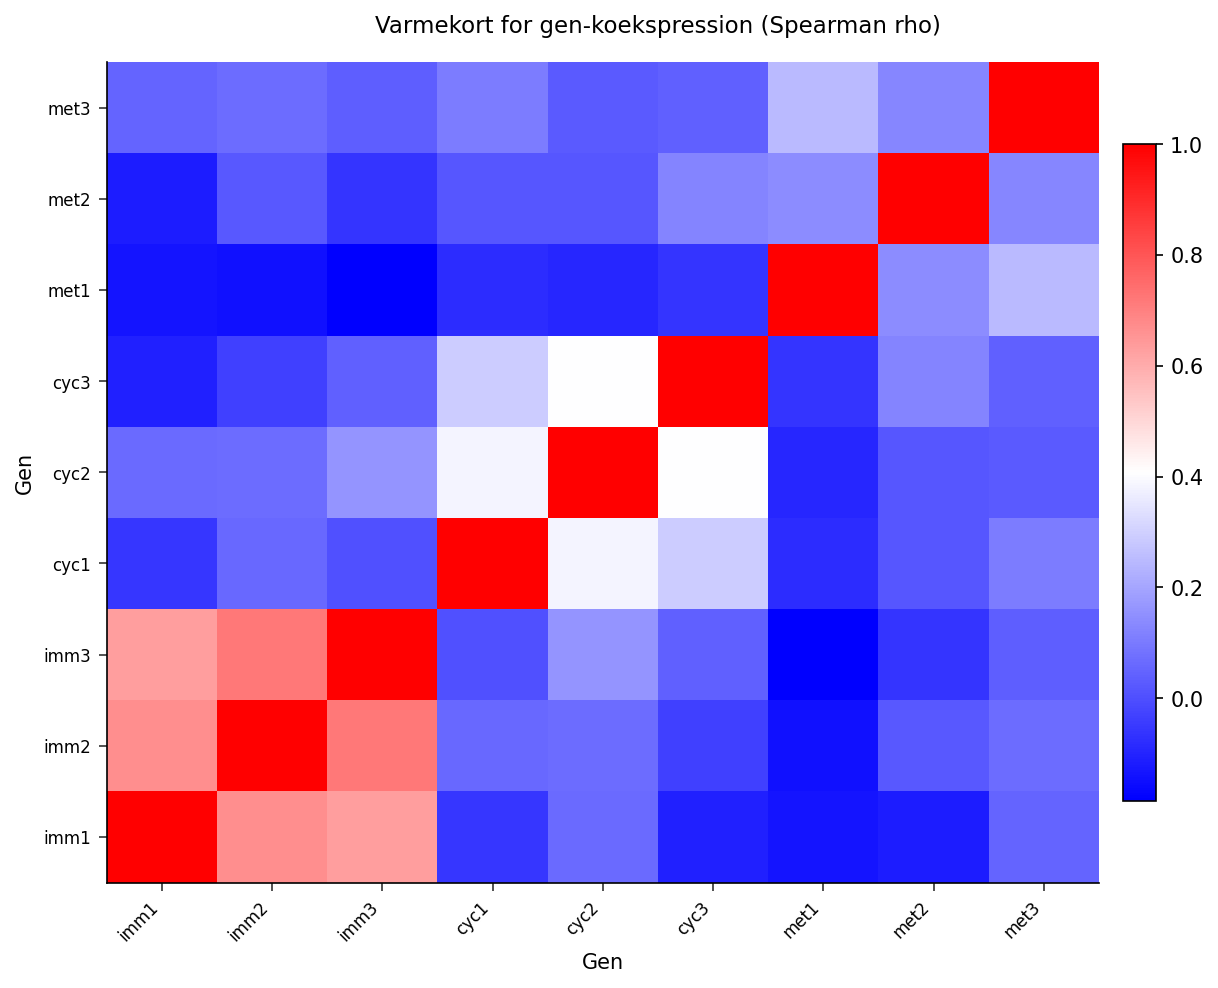

In [6]:
/* --------------------------------------------------------
   Varmekort af hele 9x9 Spearman-matricen. HEATMAPPARM plotter
   den forudberegnede rho for hvert genpar; blå-hvid-rød-skalaen
   centrerer svage par ved hvidt og mætter de stærke.
   -------------------------------------------------------- */
PROCEDURE SGPLOT data=work.corr_long;
    heatmapparm x=gene_x y=gene_y colorresponse=rho /
        colormodel=(blue white red);
    gradlegend;
    XAXIS MÆRKAT='Gen' discreteorder=data;
    YAXIS MÆRKAT='Gen' discreteorder=data;
    TITEL 'Varmekort for gen-koekspression (Spearman rho)';
KØR;
TITEL;

Tre roede blokke ligger langs diagonalen — immun-, cellecyklus- og metabolisk-modulerne —
mens de omkringliggende celler er naesten hvide. Immunblokken er den mest
maettede og svarer til dens hoejeste korrelationer inden for modulet i matricen ovenfor.

---

In [7]:
/* --------------------------------------------------------
   Netværkets kantliste: behold hvert uordnet genpar (gene_x <
   gene_y), hvis |rho| overstiger en tærskel. Disse kanter
   definerer koekspressionsnetværket til eksport til et værktøj
   som Cytoscape.
   -------------------------------------------------------- */
data work.network_edges;
    SÆT work.corr_long(HVOR=(gene_x < gene_y));
    HVIS abs(rho) >= 0.24;
KØR;

PROCEDURE UDSKRIV data=work.network_edges noobs MÆRKAT;
    VARIABEL gene_x gene_y mod_x mod_y rho;
    MÆRKAT gene_x="Gen X" gene_y="Gen Y" mod_x="Modul X" mod_y="Modul Y" rho="Spearman rho";
    TITEL 'Koekspressionsnetværkets kanter (|Spearman rho| >= 0,24)';
KØR;
TITEL;

/* Eksportér kantlisten til ekstern netværksvisualisering */
PROCEDURE EKSPORTERE data=work.network_edges
    OUTFILE='gene_coexpression_edges.csv'
    DBMS=csv REPLACE;
KØR;

                                Koekspressionsnetværkets kanter (|Spearman rho| >= 0,24)                                

Gen X  Gen Y  Modul X  Modul Y  Spearman rho
imm1   imm2   imm      imm      0.6708351085
imm1   imm3   imm      imm      0.6308427619
imm2   imm3   imm      imm      0.7179122524
cyc1   cyc2   cyc      cyc      0.3821865118
cyc1   cyc3   cyc      cyc       0.288211415
cyc2   cyc3   cyc      cyc      0.4054041891
met1   met3   met      met      0.2496024579




NOTE: DATA work.network_edges


NOTE: Read 81 rows from work.corr_long.
NOTE: Wrote work.network_edges (7 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.network_edges

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC EXPORT data=work.network_edges outfile=gene_coexpression_edges.csv

NOTE: Exported 7 rows to gene_coexpression_edges.csv.


### Fortolkning

Spearman-analysen genfandt den indbyggede tre-modulstruktur direkte fra 100
proever. Tallene nedenfor er aflaest fra PROC CORR-matricen og sammenfatningen inden for/mellem
moduler, der er produceret i denne notebook:

- **Immunmodulet (IMM1-IMM3)** er den mest taet koeksprimerede blok, med parvis rho
  fra omkring 0,63 til 0,72 (gennemsnit ~0,67) og den staerkeste enkeltkant mellem IMM2 og
  IMM3.
- **Cellecyklusmodulet (CYC1-CYC3)** er moderat koeksprimeret, med parvis rho fra
  omkring 0,29 til 0,41 (gennemsnit ~0,36).
- **Metabolisk modul (MET1-MET3)** er den svageste blok, med parvis rho fra omkring 0,13
  til 0,25 (gennemsnit ~0,17) — i overensstemmelse med dens mindre signalbelastning i generatoren.
- **Par mellem moduler** gennemsnittes til stort set nul (gennemsnitlig rho ~-0,01, gennemsnitlig |rho| ~0,07,
  stoerste |rho| ~0,18), saa de tre moduler fungerer som naesten uafhaengige faellesskaber.

Traerskelvaerdi ved |rho| >= 0,24 giver den netvaerks-kantliste, der er udskrevet ovenfor. Hver overlevende
kant er inden for et modul: alle tre immunpar og alle tre cellecykluspar klarer
traersklen, sammen med det staerkeste metaboliske par (MET1-MET3). Intet par mellem moduler
overlever, saa koekspressionsnetvaerket adskiller sig rent i de tre biologiske
moduler. Kantlisten eksporteres til `gene_coexpression_edges.csv` til visualisering i
et eksternt netvaerksvaerktoej som f.eks. Cytoscape.

Dette gennemarbejdede eksempel viser det centrale PROC CORR-arbejdsforloeb til koekspressionsanalyse: vaelg en
rangbaseret koefficient, der passer til ekspressionsdata, aflaes modulstruktur af
korrelationsmatricen, kvantificer styrken inden for kontra mellem moduler, og reducer matricen
til en traersklet kantliste til netvaerkskonstruktion.

---

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>